=== PHASE 1: LOADING DATA ===
Dataset streamed successfully from remote repository!
Dataset Size: 768 patients, 9 features

--- Features Matrix Preview ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

=== PHASE 2: CLEANING & ENGINEERING ===
Biologically impossible zeros identified in: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI

C:\Users\rehan\AppData\Local\Temp\ipykernel_9520\1397603467.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='BMI', palette='Set2')


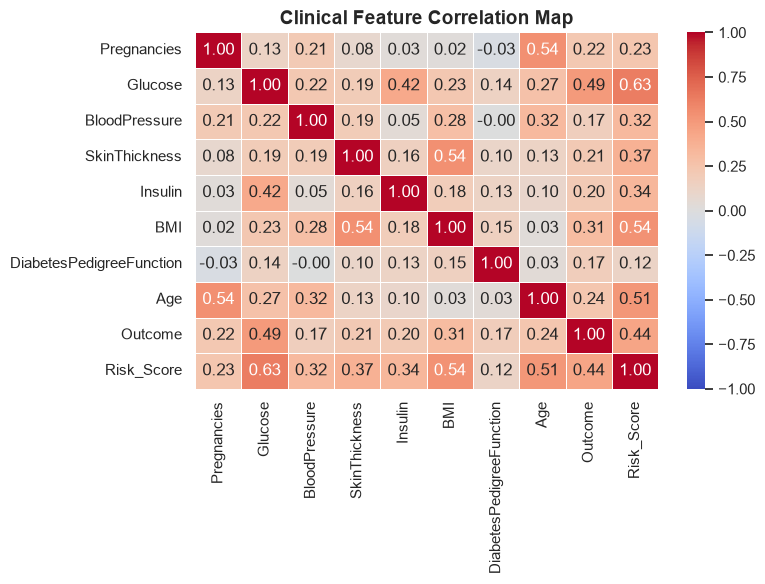

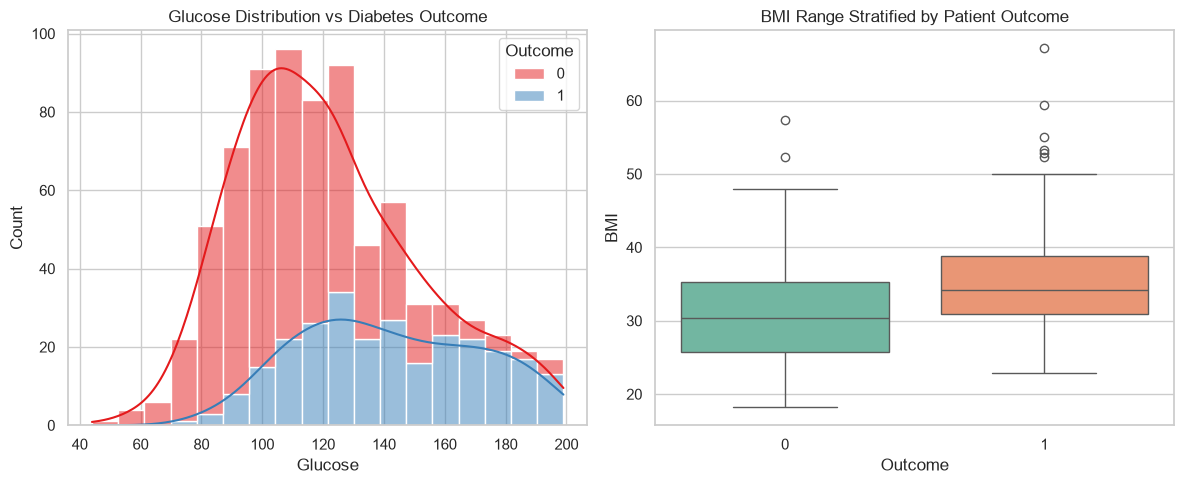

=== PHASE 4: MACHINE LEARNING PIPELINE ===
Model training execution complete.

=== PHASE 5: PERFORMANCE EVALUATION ===
Overall Model Accuracy: 0.7273

--- Classification Matrix Report ---
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



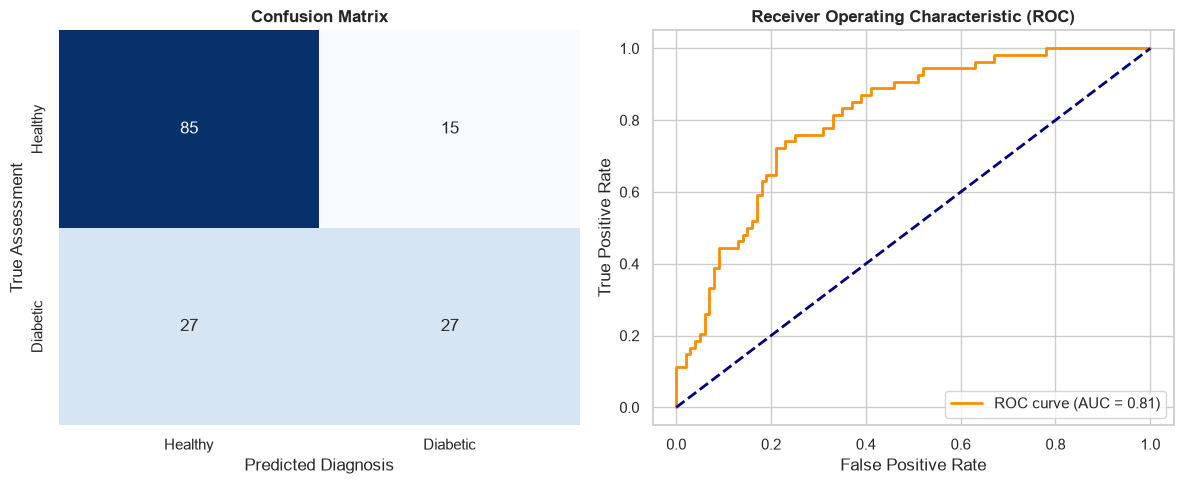

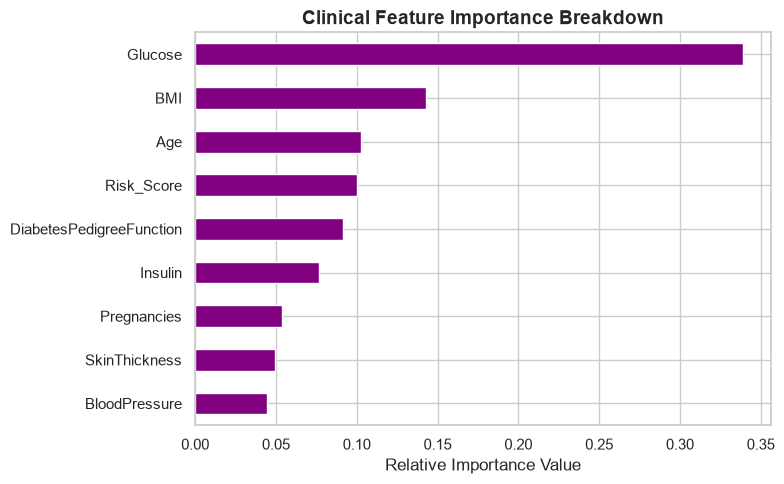

=== REAL-WORLD DATA PROJECT WORKFLOW DISPATCHED SUCCESSFULLY ===


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Set visual aesthetic configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ==========================================
# PHASE 1: DATA LOADING & INITIAL INSPECTION
# ==========================================
print("=== PHASE 1: LOADING DATA ===")
# Stream dataset directly from open-source repository
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"

try:
    df = pd.read_csv(url)
    print("Dataset streamed successfully from remote repository!")
except Exception:
    print("Remote stream failed. Attempting to read local 'diabetes.csv'...")
    df = pd.read_csv('diabetes.csv')

print(f"Dataset Size: {df.shape[0]} patients, {df.shape[1]} features\n")
print("--- Features Matrix Preview ---")
print(df.head())

# ==========================================
# PHASE 2: DATA CLEANING & FEATURE ENGINEERING
# ==========================================
print("\n=== PHASE 2: CLEANING & ENGINEERING ===")

# 1. Biological Zeros Handling
# Features like Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot biologically be 0.
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print(f"Biologically impossible zeros identified in: {invalid_zero_cols}")

# Replace 0 with NaN so they don't break statistical calculations
for col in invalid_zero_cols:
    df[col] = df[col].replace(0, np.nan)

# Impute missing NaN values using median strategies based on target distribution
for col in invalid_zero_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values/impossible values successfully imputed with median strategies.")

# 2. Feature Engineering: Risk Stratification Metric
# Creating a compounding risk score based on high-risk clinical thresholds
df['Risk_Score'] = ((df['BMI'] > 30).astype(int) + 
                    (df['Glucose'] > 140).astype(int) + 
                    (df['Age'] > 45).astype(int))
print("Feature Engineering Complete: 'Risk_Score' column appended.\n")

# ==========================================
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("=== PHASE 3: RUNNING SUMMARY VISUALIZATIONS ===")

# Plot 1: Correlation Heatmap Matrix
plt.figure(1, figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Clinical Feature Correlation Map', fontsize=14, fontweight='bold')
plt.tight_layout()

# Plot 2: Bivariate Distribution Analysis
plt.figure(2, figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, multiple="stack", palette='Set1')
plt.title('Glucose Distribution vs Diabetes Outcome')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Outcome', y='BMI', palette='Set2')
plt.title('BMI Range Stratified by Patient Outcome')
plt.tight_layout()
plt.show()

# ==========================================
# PHASE 4: ML MODEL TRAINING & PREDICTION
# ==========================================
print("=== PHASE 4: MACHINE LEARNING PIPELINE ===")

# Split features (X) and Target Label (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Train-Test Data Splitting Architecture (80/20 Rule)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Feature Scaling normalization pipeline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Initialization: Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

print("Model training execution complete.\n")

# ==========================================
# PHASE 5: ADVANCED METRICS EVALUATION
# ==========================================
print("=== PHASE 5: PERFORMANCE EVALUATION ===")
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("--- Classification Matrix Report ---")
print(classification_report(y_test, y_pred))

# Plot 3: Confusion Matrix & ROC Curve Visualization
plt.figure(3, figsize=(12, 5))

# Subplot A: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy', 'Diabetic'], yticklabels=['Healthy', 'Diabetic'])
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('True Assessment')

# Subplot B: ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()

# Plot 4: Feature Importance
plt.figure(4, figsize=(8, 5))
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='purple')
plt.title('Clinical Feature Importance Breakdown', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Value')
plt.tight_layout()
plt.show()

print("=== REAL-WORLD DATA PROJECT WORKFLOW DISPATCHED SUCCESSFULLY ===")